In [27]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import pandas as pd
import seaborn as sns

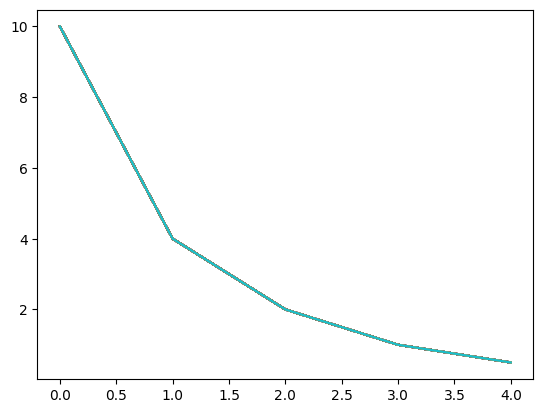

In [28]:
N_p = 100 # patients
N_t = 5 # time points (number of)
sc = 12 # scaling factor

y0 = np.zeros((N_p, N_t)) + np.array([10, 4, 2, 1, .5])

plt.plot(y0.T)
plt.show()

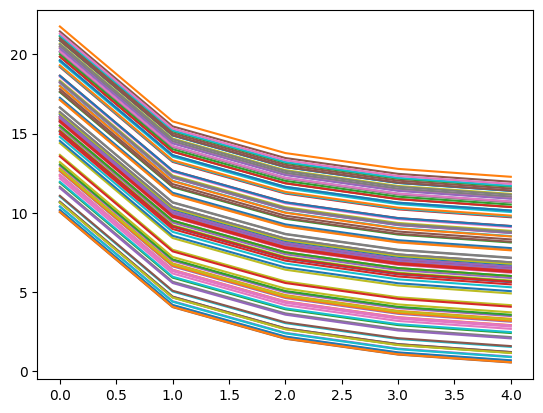

In [29]:
y_add = y0 + np.random.rand(N_p)[:, None] * sc

plt.plot(y_add.T)
plt.show()

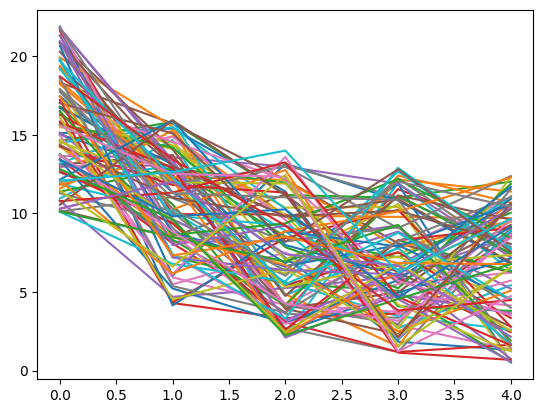

In [30]:
y_mult = y0 + np.random.rand(N_p, N_t) * sc

plt.plot(y_mult.T)
plt.show()

In [31]:
df_add = pd.DataFrame(data=y_add, columns=[f'T{i}' for i in range(N_t)])
df_add['Patient'] = np.arange(N_p) + 100
df_add = pd.melt(df_add, id_vars='Patient', value_vars=[f'T{i}' for i in range(N_t)], var_name='Week', value_name='y')

model = smf.mixedlm('y ~ Week', data=df_add, groups='Patient').fit()

model.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
            Mixed Linear Model Regression Results
=============================================================
Model:              MixedLM   Dependent Variable:   y        
No. Observations:   500       Method:               REML     
No. Groups:         100       Scale:                0.0000   
Min. group size:    5         Log-Likelihood:       3626.7398
Max. group size:    5         Converged:            Yes      
Mean group size:    5.0                                      
-------------------------------------------------------------
            Coef.   Std.Err.      z       P>|z| [0.025 0.975]
-------------------------------------------------------------
Intercept   16.172     0.155      104.598 0.000 15.869 16.475
Week[T.T1]  -6.000     0.000 -3331941.510 0.000 -6.000 -6.000
Week[T.T2]  -8.000     0.000 -4442588.680 0.000 -8.000 -8.000
Week[T.T3]  -9.000     0.000 -4997912.265 0.000 -9.000 -9.000
Week[T.T4]  -9.500     0.000 -5275574.057 0.000 -9.500 -9.500
Patient Var  2.390 13341.498                                 
=============================================================

"""

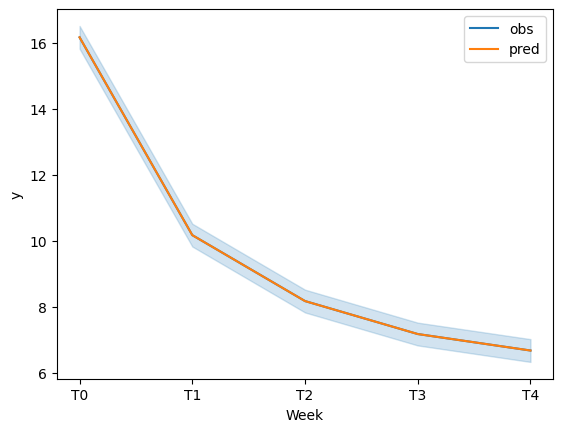

In [32]:
fe_params = model.fe_params.to_numpy()
bse = model.bse_fe.to_numpy()
b = fe_params.copy()
sem = bse.copy()
b[1:] += b[0] 
sem[1:] += sem[0]
sns.lineplot(data=df_add, x='Week', y='y', errorbar='se', label= 'obs')
plt.plot(b, label = 'pred')
plt.legend()
plt.show()
#plt.fill_between(df_add.Week.unique(), b-sem, b+sem)

In [33]:
kill = np.random.randint(low=0, high=500, size=200)
df_add_kill = df_add.drop(index=kill)

model = smf.mixedlm('y ~ Week', data=df_add_kill, groups='Patient').fit()

model.summary()


<class 'statsmodels.iolib.summary2.Summary'>
"""
            Mixed Linear Model Regression Results
=============================================================
Model:              MixedLM   Dependent Variable:   y        
No. Observations:   341       Method:               REML     
No. Groups:         100       Scale:                0.0000   
Min. group size:    1         Log-Likelihood:       1893.1408
Max. group size:    5         Converged:            Yes      
Mean group size:    3.4                                      
-------------------------------------------------------------
            Coef.   Std.Err.      z       P>|z| [0.025 0.975]
-------------------------------------------------------------
Intercept   16.172     0.188       86.177 0.000 15.804 16.540
Week[T.T1]  -6.000     0.000 -1269402.779 0.000 -6.000 -6.000
Week[T.T2]  -8.000     0.000 -1686577.339 0.000 -8.000 -8.000
Week[T.T3]  -9.000     0.000 -1827355.363 0.000 -9.000 -9.000
Week[T.T4]  -9.500     0.000 -2017666.288 0.000 -9.500 -9.500
Patient Var  3.522 12328.942                                 
=============================================================

"""

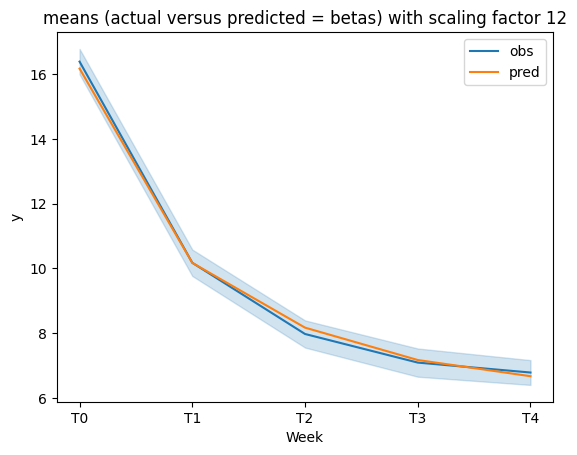

In [34]:
fe_params = model.fe_params.to_numpy()
bse = model.bse_fe.to_numpy()
b = fe_params.copy()
sem = bse.copy()

# bi + b0 = mean(timepoint i) for i != 0
b[1:] += b[0] 
sem[1:] += sem[0]

sns.lineplot(data=df_add_kill, x='Week', y='y', errorbar='se', label = 'obs')
plt.plot(b,label = 'pred')

plt.legend()
plt.title(f"means (actual versus predicted = betas) with scaling factor {sc}")
plt.show()

## Multiplicative differences

Additive differences between subjs: should make sense to use the intercept (fitted lines will be additively different by subj_intercept (re) value).

Multiplicative:

In [35]:
df_mult = pd.DataFrame(data=y_mult, columns=[f'T{i}' for i in range(N_t)])
df_mult['Patient'] = np.arange(N_p) + 100
df_mult = pd.melt(df_mult, id_vars='Patient', value_vars=[f'T{i}' for i in range(N_t)], var_name='Week', value_name='y')

model = smf.mixedlm('y ~ Week', data=df_mult, groups='Patient').fit()

model.summary()

/home/UWO/mporwal2/Documents/GitHub/smarts_cerebellum/.venv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


<class 'statsmodels.iolib.summary2.Summary'>
"""
         Mixed Linear Model Regression Results
========================================================
Model:            MixedLM Dependent Variable: y         
No. Observations: 500     Method:             REML      
No. Groups:       100     Scale:              11.8367   
Min. group size:  5       Log-Likelihood:     -1325.5108
Max. group size:  5       Converged:          Yes       
Mean group size:  5.0                                   
--------------------------------------------------------
            Coef.  Std.Err.    z    P>|z|  [0.025 0.975]
--------------------------------------------------------
Intercept   15.860    0.344  46.100 0.000  15.186 16.535
Week[T.T1]  -5.083    0.487 -10.447 0.000  -6.036 -4.129
Week[T.T2]  -8.506    0.487 -17.481 0.000  -9.459 -7.552
Week[T.T3]  -9.136    0.487 -18.777 0.000 -10.090 -8.182
Week[T.T4]  -9.088    0.487 -18.678 0.000 -10.041 -8.134
Patient Var  0.000    0.112                             
========================================================

"""

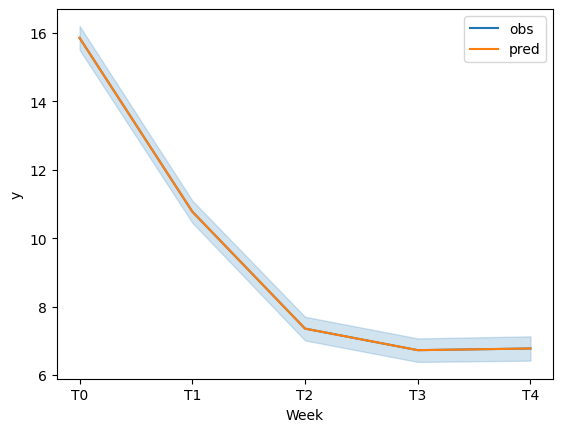

In [36]:
fe_params = model.fe_params.to_numpy()
bse = model.bse_fe.to_numpy()
b = fe_params.copy()
sem = bse.copy()
b[1:] += b[0] 
sem[1:] += sem[0]
sns.lineplot(data=df_mult, x='Week', y='y', errorbar='se', label= 'obs')
plt.plot(b, label = 'pred')
plt.legend()
plt.show()
#plt.fill_between(df_add.Week.unique(), b-sem, b+sem)

In [37]:
# same values killed as with the additive model
df_mult_kill = df_mult.drop(index=kill)

model = smf.mixedlm('y ~ Week', data=df_mult_kill, groups='Patient').fit()

model.summary()


/home/UWO/mporwal2/Documents/GitHub/smarts_cerebellum/.venv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


<class 'statsmodels.iolib.summary2.Summary'>
"""
         Mixed Linear Model Regression Results
=======================================================
Model:            MixedLM Dependent Variable: y        
No. Observations: 341     Method:             REML     
No. Groups:       100     Scale:              12.4045  
Min. group size:  1       Log-Likelihood:     -910.3485
Max. group size:  5       Converged:          Yes      
Mean group size:  3.4                                  
-------------------------------------------------------
            Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept   15.548    0.421  36.923 0.000 14.723 16.373
Week[T.T1]  -5.064    0.593  -8.536 0.000 -6.226 -3.901
Week[T.T2]  -8.004    0.598 -13.393 0.000 -9.175 -6.833
Week[T.T3]  -8.760    0.620 -14.132 0.000 -9.975 -7.545
Week[T.T4]  -8.658    0.594 -14.581 0.000 -9.822 -7.494
Patient Var  0.000    0.171                            
=======================================================

"""

In [38]:
# df of just the predicted means

df_mult_kill_b = pd.DataFrame(model.fe_params.to_numpy(), columns = ['y_pred'])
timepoints = df_mult_kill.Week.unique()
df_mult_kill_b['Week'] = timepoints
df_mult_kill_b['se'] = model.bse_fe.to_numpy() # se of betas (fixed effects se)

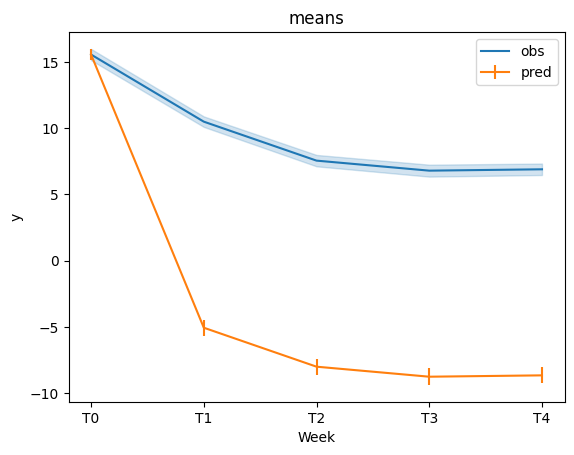

In [39]:
sns.lineplot(data=df_mult_kill, x='Week', y='y', errorbar='se', label = 'obs')
#plt.plot(b, label = 'pred')
#sns.lineplot(data = df_mult_kill_b, x='Week', y='y_pred', label = 'pred')
plt.errorbar(data = df_mult_kill_b, x='Week', y='y_pred', yerr = 'se', label = 'pred')
plt.legend()
plt.title(f"means")
plt.show()